In [1]:
from collections import defaultdict
import os
import random
import numpy as np
import pandas as pd
import json
import pickle
import gzip
from tqdm import tqdm

def load_pickle(filename):
    with open(filename, "rb") as f:
        return pickle.load(f)


def save_pickle(data, filename):
    with open(filename, "wb") as f:
        pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)

def load_json(file_path):
    with open(file_path, "r") as f:
        return json.load(f)
    
def ReadLineFromFile(path):
    lines = []
    with open(path,'r') as fd:
        for line in fd:
            lines.append(line.rstrip('\n'))
    return lines

def parse(path):
    g = gzip.open(path, 'r')
    for l in g:
        # l = l.replace('false', 'False').replace('true', 'True')
        # Convert bytes to string
        data_str = l.decode('utf-8')
        # Replace 'false' with 'False' and 'true' with 'True'
        data_str = data_str.replace('false', 'False').replace('true', 'True')

        # Parse the JSON string into a dictionary
        yield eval(data_str)
'''
Set seeds
'''
seed = 999
random.seed(seed)
np.random.seed(seed)

In [2]:
short_data_name = 'clothing'

# Create Splits for Review

In [3]:
datamaps = load_json("data/{}/datamaps.json".format(short_data_name))
print(datamaps.keys())

dict_keys(['user2id', 'item2id', 'id2user', 'id2item', 'attribute2id', 'id2attribute', 'attributeid2num'])


In [4]:
exp_data = load_pickle("data/{}/exp_splits.pkl".format(short_data_name))
exp_data.keys()

dict_keys(['train', 'val', 'test'])

In [5]:
rev_data = load_pickle("data/{}/review_splits.pkl".format(short_data_name))
rev_data.keys()

dict_keys(['train', 'val', 'test', 'train_indices', 'val_indices', 'test_indices'])

In [6]:
seq_data = ReadLineFromFile(f"data/{short_data_name}/sequential_data.txt")
len(seq_data)

39387

In [7]:
users, items = len(datamaps['user2id']), len(datamaps['item2id'])
count = len(rev_data['train']) + len(rev_data['test']) + len(rev_data['val'])
print("# Users: ",users)
print("# Items: ",items)
print("# Reviews: ",count)
print("Sparsity: ",count * 100.0 / (users * items),'%')

# Users:  39387
# Items:  23033
# Reviews:  278677
Sparsity:  0.03071833809100676 %


# Percentile of target items and interaction count cumulative

In [8]:
item_count = defaultdict(int)
user_items = defaultdict()
for line in seq_data:
    user, items = line.strip().split(' ', 1)
    items = items.split(' ')
    items = [int(item) for item in items]
    user_items[user] = items
    for item in items:
        item_count[item] += 1

In [9]:
import matplotlib.pyplot as plt

def analyze_popularity_cutoffs(item_counts,dataset, cutoffs=[0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]):
    # Step 1: Compute item interaction counts
    item_freq_df = pd.DataFrame(
        [(item, count) for item, count in item_counts.items()],
        columns=["item", "count"]
    )
    item_freq_df = item_freq_df.sort_values(by='count', ascending=False).reset_index(drop=True)

    total_interactions = item_freq_df['count'].sum()
    total_items = len(item_freq_df)

    # Step 2: Evaluate different top-k% popularity cutoffs
    summary_records = []
    for cutoff in cutoffs:
        num_items = max(1, int(cutoff * total_items))
        top_items = item_freq_df.iloc[:num_items]
        cumulative_interactions = top_items['count'].sum()
        contribution_percent = cumulative_interactions / total_interactions

        summary_records.append({
            'Top_k_percent': cutoff * 100,
            'Num_Items': num_items,
            'Interaction_Contribution (%)': contribution_percent * 100
        })

    summary_df = pd.DataFrame(summary_records)

    # Step 3: Plot
    plt.figure(figsize=(8, 5))
    plt.plot(summary_df['Top_k_percent'], summary_df['Interaction_Contribution (%)'], marker='o')
    plt.xlabel('Top-K% Popular Items')
    plt.ylabel('Cumulative Interaction Contribution (%)')
    plt.title(f'{dataset.upper()}: Contribution of Top-K% Popular Items to Total Interactions')
    plt.grid(True)
    plt.xticks(summary_df['Top_k_percent'])
    plt.tight_layout()
    plt.show()

    return summary_df


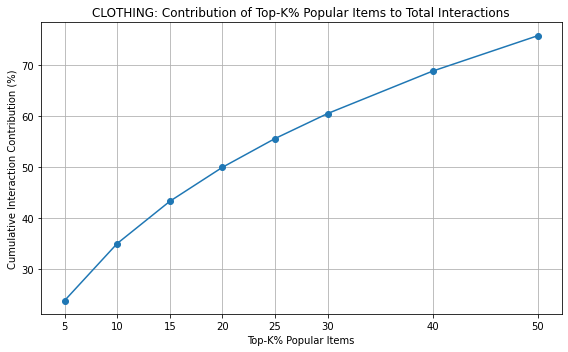

In [10]:
df = analyze_popularity_cutoffs(item_count,short_data_name)

In [11]:
print(f"{short_data_name.upper()}")
df

CLOTHING


,Top_k_percent,Num_Items,Interaction_Contribution (%)
0,5.0,1151,23.821485
1,10.0,2303,35.015807
2,15.0,3454,43.299591
3,20.0,4606,49.967884
4,25.0,5758,55.610976
5,30.0,6909,60.519526
6,40.0,9213,68.859289
7,50.0,11516,75.810347
